In [1]:
# step 1 : import libararies

# import common libararies

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings 
warnings.filterwarnings('ignore')

# import sklearns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, RepeatedKFold, ShuffleSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, auc, roc_curve, roc_auc_score, ConfusionMatrixDisplay

# import classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
# step 2 : load dataset

df = pd.read_csv('personality_dataset.csv')

# displaying first five rows of the dataset

df.head()

,Time spent Alone,Stage fear,Social event attendance,Going outside,Drained after socializing,Friends circle size,Post frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [3]:
# step 3 : dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time spent Alone           2837 non-null   float64
 1   Stage fear                 2827 non-null   object 
 2   Social event attendance    2838 non-null   float64
 3   Going outside              2834 non-null   float64
 4   Drained after socializing  2848 non-null   object 
 5   Friends circle size        2823 non-null   float64
 6   Post frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [4]:
# dataset description

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time spent Alone,2837.0,4.505816,3.479192,0.0,2.0,4.0,8.0,11.0
Social event attendance,2838.0,3.963354,2.903827,0.0,2.0,3.0,6.0,10.0
Going outside,2834.0,3.000000,2.247327,0.0,1.0,3.0,5.0,7.0
Friends circle size,2823.0,6.268863,4.289693,0.0,3.0,5.0,10.0,15.0
Post frequency,2835.0,3.564727,2.926582,0.0,1.0,3.0,6.0,10.0


In [5]:
# dataset shape and size

print("Dataset Shape :", df.shape)
print("Dataset Size :", df.size)

Dataset Shape : (2900, 8)
Dataset Size : 23200


In [6]:
# step 4 : dataset cleaning 

# before cleaning column names

print("Column names before cleaning :", df.columns)

# cleaning column names 

df.columns = df.columns.str.strip().str.replace('[^a-zA-Z0-9_]', '_', regex = True).str.strip('_')

# after cleaning column names

print("\nColumn names after cleaning :", df.columns)

Column names before cleaning : Index(['Time spent Alone', 'Stage fear', 'Social event attendance',
       'Going outside', 'Drained after socializing', 'Friends circle size',
       'Post frequency', 'Personality'],
      dtype='object')

Column names after cleaning : Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')


In [7]:
# checking for duplicate values

print("Duplicate values count before cleaning :", df.duplicated().sum())

# cleaning duplicate values

df.drop_duplicates(inplace = True)

# after cleaning for null values

print("Duplicate values count after cleaning :", df.duplicated().sum())

Duplicate values count before cleaning : 388
Duplicate values count after cleaning : 0


In [8]:
# checking for null values

print("Null values count before cleaning :\n", df.isnull().sum())

# filling numeric values with mean

num_cols = df.select_dtypes(include = 'float64').columns

for i in num_cols:
    df[i] = df[i].fillna(df[i].mean())

# filling category values with mode

cat_cols = df.select_dtypes(include = 'object').columns

for i in cat_cols:
    df[i] = df[i].fillna(df[i].mode()[0])

# after cleaning for null values

print("\nNull values count after cleaning :\n", df.isnull().sum())

Null values count before cleaning :
 Time_spent_Alone             61
Stage_fear                   73
Social_event_attendance      61
Going_outside                65
Drained_after_socializing    51
Friends_circle_size          75
Post_frequency               63
Personality                   0
dtype: int64

Null values count after cleaning :
 Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64


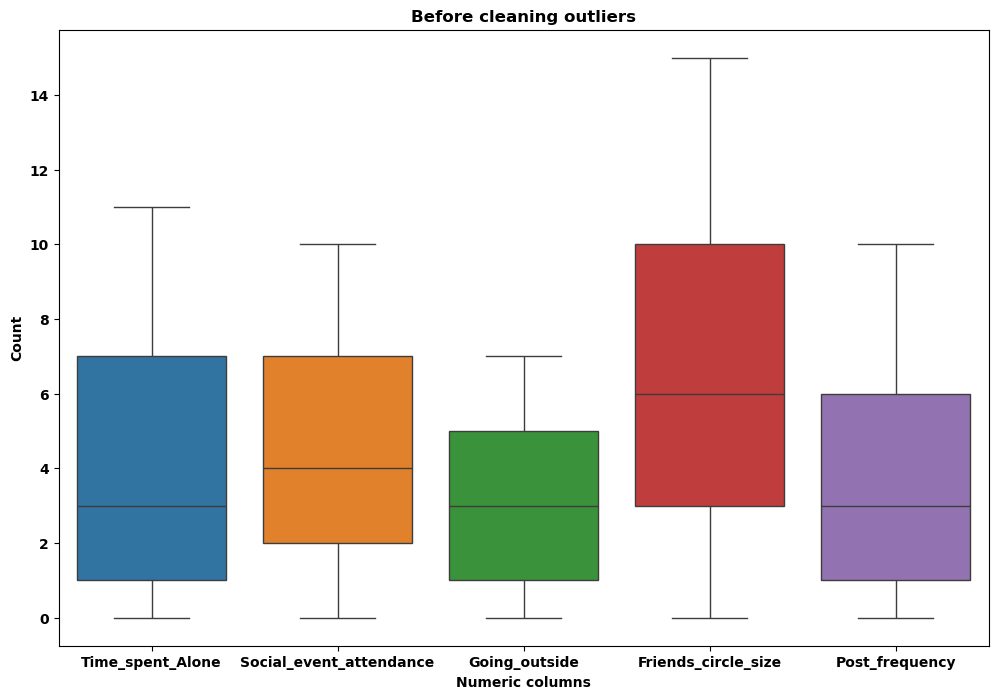

In [9]:
# checking for outliers

num_cols = df.select_dtypes(include = 'float64')

plt.figure(figsize = (12, 8))
plt.title("Before cleaning outliers", fontweight = 'bold')
sns.boxplot(data = num_cols)
plt.xlabel("Numeric columns", fontweight = 'bold')
plt.ylabel("Count", fontweight = 'bold')
plt.xticks(fontweight = 'bold')
plt.yticks(fontweight = 'bold')
plt.show()


===== Outliers =====

Before cleaning outlier : (2512, 8)
After cleaning outlier  : (2512, 8)


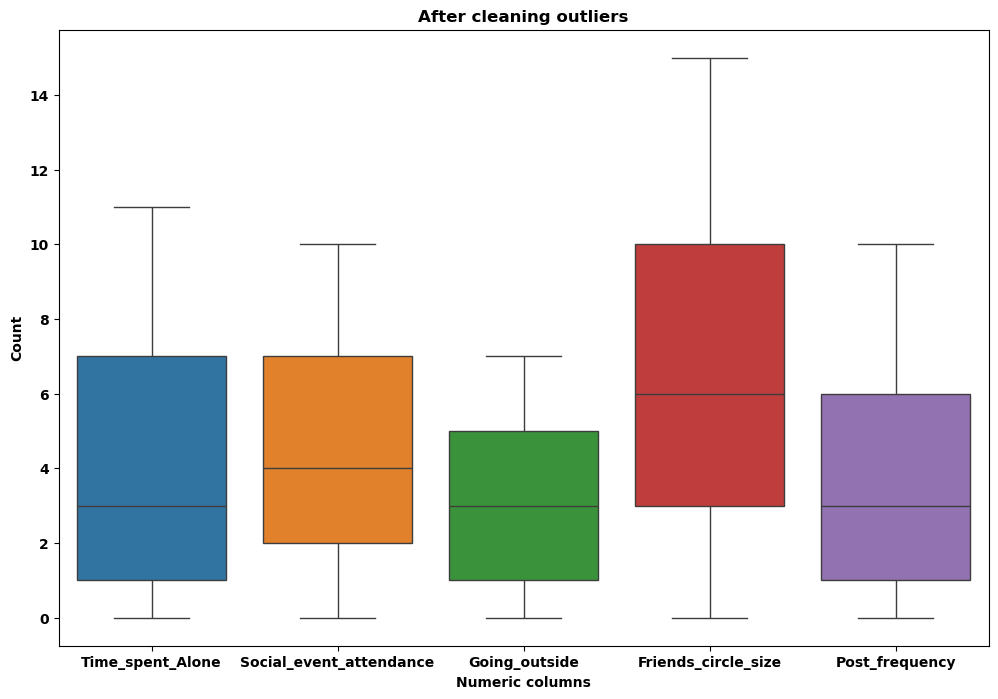

In [10]:
# cleaning outliers

df_clean = df.copy()

num_cols = df.select_dtypes(include = 'float64')
for i in num_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 *  IQR
    upper_bound = Q3 + 1.5 *  IQR
    df_clean = df_clean[(df[i] >= lower_bound) & (df[i] <= upper_bound)]

print("\n===== Outliers =====\n")
print("Before cleaning outlier :", df.shape)
print("After cleaning outlier  :", df_clean.shape)

# after cleaning outliers

num_cols = df_clean.select_dtypes(include = 'float64')

plt.figure(figsize = (12, 8))
plt.title("After cleaning outliers", fontweight = 'bold')
sns.boxplot(data = num_cols)
plt.xlabel("Numeric columns", fontweight = 'bold')
plt.ylabel("Count", fontweight = 'bold')
plt.xticks(fontweight = 'bold')
plt.yticks(fontweight = 'bold')
plt.show()

In [11]:
# step 5 : feature engineering

# rounding null filled values

num_cols = df_clean.select_dtypes(include = 'float64').columns

for i in num_cols:
    df_clean[i] = df[i].round().astype(int)

In [12]:
# step 6 : data summarization

df.groupby('Personality')['Stage_fear'].value_counts().reset_index(name = 'Count').sort_values(['Personality', 'Count'], ascending = [True, False])

,Personality,Stage_fear,Count
0,Extrovert,No,1312
1,Extrovert,Yes,105
2,Introvert,Yes,986
3,Introvert,No,109


In [13]:
df.groupby('Personality')['Drained_after_socializing'].value_counts().reset_index(name = 'Count').sort_values(['Personality', 'Count'], ascending = [True, False])

,Personality,Drained_after_socializing,Count
0,Extrovert,No,1312
1,Extrovert,Yes,105
2,Introvert,Yes,984
3,Introvert,No,111


In [14]:
a = df_clean.query("Time_spent_Alone < 4").shape[0]
print("Time Spend Alone (0 - 3 hrs) :", a)

b = df_clean.query("Time_spent_Alone > 3 and Time_spent_Alone < 8").shape[0]
print("Time Spend Alone (4 - 7 hrs) :", b)

c = df_clean.query("Time_spent_Alone > 7").shape[0]
print("Time Spend Alone (8 - 11 hrs) :", c)

Time Spend Alone (0 - 3 hrs) : 1336
Time Spend Alone (4 - 7 hrs) : 618
Time Spend Alone (8 - 11 hrs) : 558


In [15]:
d = df_clean.query("Time_spent_Alone < 4 and Personality == 'Extrovert'").shape[0]
print("Extrovert People Time Spend Alone (0 - 3 hrs) :", d)

e = df_clean.query("Time_spent_Alone < 4 and Personality == 'Introvert'").shape[0]
print("Introvert People Time Spend Alone (0 - 3 hrs) :", e)

f = df_clean.query("Time_spent_Alone > 3 and Time_spent_Alone < 8 and Personality == 'Extrovert'").shape[0]
print("\nExtrovert People Time Spend Alone (4 - 7 hrs) :", f)

g = df_clean.query("Time_spent_Alone > 3 and Time_spent_Alone < 8 and Personality == 'Introvert'").shape[0]
print("Introvert People Time Spend Alone (4 - 7 hrs) :", g)

h = df_clean.query("Time_spent_Alone > 7 and Personality == 'Extrovert'").shape[0]
print("\nExtrovert People Time Spend Alone (8 - 11 hrs) :", h)

i = df_clean.query("Time_spent_Alone > 7 and Personality == 'Introvert'").shape[0]
print("Introvert People Time Spend Alone (8 - 11 hrs) :", i)

Extrovert People Time Spend Alone (0 - 3 hrs) : 1259
Introvert People Time Spend Alone (0 - 3 hrs) : 77

Extrovert People Time Spend Alone (4 - 7 hrs) : 88
Introvert People Time Spend Alone (4 - 7 hrs) : 530

Extrovert People Time Spend Alone (8 - 11 hrs) : 70
Introvert People Time Spend Alone (8 - 11 hrs) : 488


In [16]:
j = df_clean.query("Social_event_attendance < 4").shape[0]
print("Social Event Attendance (0 - 3 hrs) :", j)

k = df_clean.query("Social_event_attendance > 3 and Social_event_attendance < 8").shape[0]
print("Social Event Attendance (4 - 7 hrs) :", k)

l = df_clean.query("Social_event_attendance > 7").shape[0]
print("Social Event Attendance (8 - 10 hrs) :", l)

Social Event Attendance (0 - 3 hrs) : 1107
Social Event Attendance (4 - 7 hrs) : 970
Social Event Attendance (8 - 10 hrs) : 435


In [17]:
m = df_clean.query("Social_event_attendance < 4 and Personality == 'Extrovert'").shape[0]
print("Extrovert People Social Event Attendance (0 - 3 hrs) :", m)

n = df_clean.query("Social_event_attendance < 4 and Personality == 'Introvert'").shape[0]
print("Introvert People Social Event Attendance (0 - 3 hrs) :", n)

o = df_clean.query("Social_event_attendance > 3 and Social_event_attendance < 8 and Personality == 'Extrovert'").shape[0]
print("\nExtrovert People Social Event Attendance (4 - 7 hrs) :", o)

p = df_clean.query("Social_event_attendance > 3 and Social_event_attendance < 8 and Personality == 'Introvert'").shape[0]
print("Introvert People Social Event Attendance (4 - 7 hrs) :", p)

q = df_clean.query("Social_event_attendance > 7 and Personality == 'Extrovert'").shape[0]
print("\nExtrovert People Social Event Attendance (8 - 10 hrs) :", q)

r = df_clean.query("Social_event_attendance > 7 and Personality == 'Introvert'").shape[0]
print("Introvert People Social Event Attendance (8 - 10 hrs) :", r)

Extrovert People Social Event Attendance (0 - 3 hrs) : 122
Introvert People Social Event Attendance (0 - 3 hrs) : 985

Extrovert People Social Event Attendance (4 - 7 hrs) : 891
Introvert People Social Event Attendance (4 - 7 hrs) : 79

Extrovert People Social Event Attendance (8 - 10 hrs) : 404
Introvert People Social Event Attendance (8 - 10 hrs) : 31


In [18]:
s = df_clean.query("Going_outside < 3").shape[0]
print("Going Outside (0 - 2 hrs) :", s)

t = df_clean.query("Going_outside > 2 and Social_event_attendance < 6").shape[0]
print("Going Outside (3 - 5 hrs) :", t)

u = df_clean.query("Going_outside > 5").shape[0]
print("Going Outside (6 - 7 hrs) :", u)

Going Outside (0 - 2 hrs) : 1065
Going Outside (3 - 5 hrs) : 559
Going Outside (6 - 7 hrs) : 485


In [19]:
v = df_clean.query("Going_outside < 3 and Personality == 'Extrovert'").shape[0]
print("Extrovert People Going Outside (0 - 2 hrs) :", v)

w = df_clean.query("Going_outside < 3 and Personality == 'Introvert'").shape[0]
print("Introvert People Going Outside (0 - 2 hrs) :", w)

x = df_clean.query("Going_outside > 2 and Going_outside < 6 and Personality == 'Extrovert'").shape[0]
print("\nExtrovert People Going Outside (3 - 5 hrs) :", x)

y = df_clean.query("Going_outside > 2 and Going_outside < 6 and Personality == 'Introvert'").shape[0]
print("Introvert People Going Outside (3 - 5 hrs) :", y)

z = df_clean.query("Going_outside > 5 and Personality == 'Extrovert'").shape[0]
print("\nExtrovert People Going Outside (6 - 7 hrs) :", z)

aa = df_clean.query("Going_outside > 5 and Personality == 'Introvert'").shape[0]
print("Introvert People Going Outside (6 - 7 hrs) :", aa)

Extrovert People Going Outside (0 - 2 hrs) : 104
Introvert People Going Outside (0 - 2 hrs) : 961

Extrovert People Going Outside (3 - 5 hrs) : 867
Introvert People Going Outside (3 - 5 hrs) : 95

Extrovert People Going Outside (6 - 7 hrs) : 446
Introvert People Going Outside (6 - 7 hrs) : 39


In [20]:
bb = df_clean.query("Friends_circle_size < 6").shape[0]
print("Friends Circle Size (0 - 5 hrs) :", bb)

cc = df_clean.query("Friends_circle_size > 5 and Friends_circle_size < 11").shape[0]
print("Friends Circle Size (6 - 10 hrs) :", cc)

dd = df_clean.query("Friends_circle_size > 10").shape[0]
print("Friends Circle Size (11 - 15 hrs) :", dd)

Friends Circle Size (0 - 5 hrs) : 1181
Friends Circle Size (6 - 10 hrs) : 760
Friends Circle Size (11 - 15 hrs) : 571


In [21]:
ee = df_clean.query("Friends_circle_size < 6 and Personality == 'Extrovert'").shape[0]
print("Extrovert People Friends Circle Size (0 - 5 hrs) :", ee)

ff = df_clean.query("Friends_circle_size < 6 and Personality == 'Introvert'").shape[0]
print("Introvert People Friends Circle Size (0 - 5 hrs) :", ff)

gg = df_clean.query("Friends_circle_size > 5 and Friends_circle_size < 11 and Personality == 'Extrovert'").shape[0]
print("\nExtrovert People Friends Circle Size (6 - 10 hrs) :", gg)

hh = df_clean.query("Friends_circle_size > 5 and Friends_circle_size < 11 and Personality == 'Introvert'").shape[0]
print("Introvert People Friends Circle Size (6 - 10 hrs) :", hh)

ii = df_clean.query("Friends_circle_size > 10 and Personality == 'Extrovert'").shape[0]
print("\nExtrovert People Friends Circle Size (11 - 15 hrs) :", ii)

jj = df_clean.query("Friends_circle_size > 10 and Personality == 'Introvert'").shape[0]
print("Introvert People Friends Circle Size (11 - 15 hrs) :", jj)

Extrovert People Friends Circle Size (0 - 5 hrs) : 199
Introvert People Friends Circle Size (0 - 5 hrs) : 982

Extrovert People Friends Circle Size (6 - 10 hrs) : 696
Introvert People Friends Circle Size (6 - 10 hrs) : 64

Extrovert People Friends Circle Size (11 - 15 hrs) : 522
Introvert People Friends Circle Size (11 - 15 hrs) : 49


In [22]:
kk = df_clean.query("Post_frequency < 4").shape[0]
print("Post Frequency (0 - 3 hrs) :", kk)

ll = df_clean.query("Post_frequency > 3 and Post_frequency < 8").shape[0]
print("Post Frequency (4 - 7 hrs) :", ll)

mm = df_clean.query("Post_frequency > 7").shape[0]
print("Post Frequency (8 - 10 hrs) :", mm)

Post Frequency (0 - 3 hrs) : 1270
Post Frequency (4 - 7 hrs) : 865
Post Frequency (8 - 10 hrs) : 377


In [23]:
nn = df_clean.query("Post_frequency < 4 and Personality == 'Extrovert'").shape[0]
print("Extrovert People Post Frequency (0 - 3 hrs) :", nn)

oo = df_clean.query("Post_frequency < 4 and Personality == 'Introvert'").shape[0]
print("Introvert People Post Frequency (0 - 3 hrs) :", oo)

pp = df_clean.query("Post_frequency > 3 and Post_frequency < 8 and Personality == 'Extrovert'").shape[0]
print("\nExtrovert People Post Frequency (4 - 7 hrs) :", pp)

qq = df_clean.query("Post_frequency > 3 and Post_frequency < 8 and Personality == 'Introvert'").shape[0]
print("Introvert People Post Frequency (4 - 7 hrs) :", qq)

rr = df_clean.query("Post_frequency > 7 and Personality == 'Extrovert'").shape[0]
print("\nExtrovert People Post Frequency (8 - 10 hrs) :", rr)

ss = df_clean.query("Post_frequency > 7 and Personality == 'Introvert'").shape[0]
print("Introvert People Post Frequency (8 - 10 hrs) :", ss)

Extrovert People Post Frequency (0 - 3 hrs) : 279
Introvert People Post Frequency (0 - 3 hrs) : 991

Extrovert People Post Frequency (4 - 7 hrs) : 785
Introvert People Post Frequency (4 - 7 hrs) : 80

Extrovert People Post Frequency (8 - 10 hrs) : 353
Introvert People Post Frequency (8 - 10 hrs) : 24


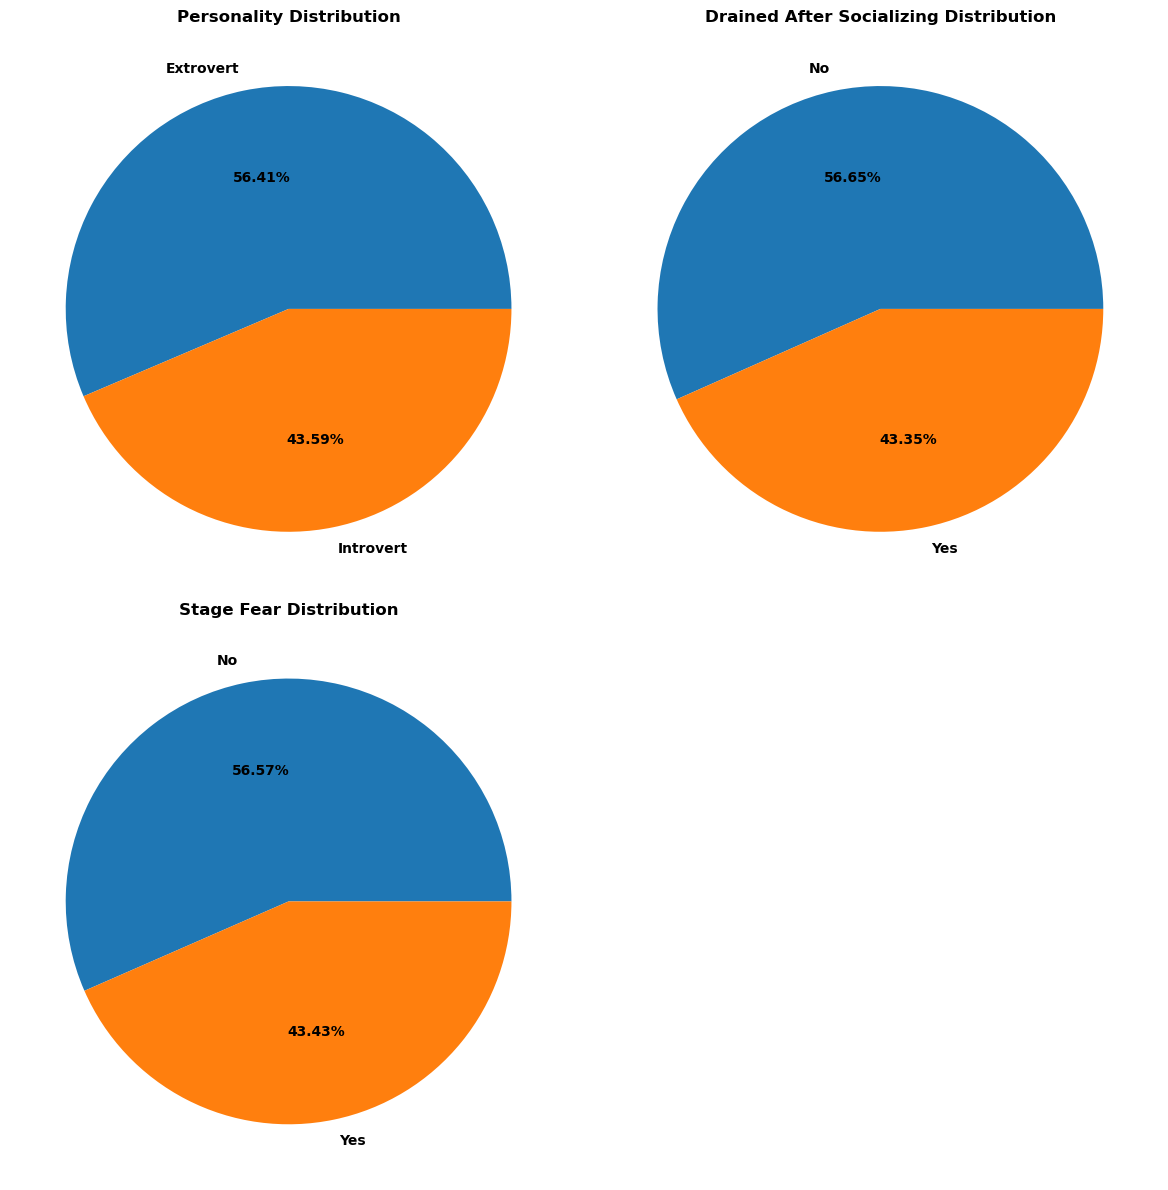

In [24]:
# step 7 : eda

plt.figure(figsize = (12, 12))

plt.subplot(221)
tt = df_clean['Personality'].value_counts()
plt.title("Personality Distribution", fontweight = 'bold')
plt.pie(tt.values, labels = tt.index, autopct = '%1.2f%%', textprops = {'fontweight' : 'bold'})

plt.subplot(222)
uu = df_clean['Drained_after_socializing'].value_counts()
plt.title("Drained After Socializing Distribution", fontweight = 'bold')
plt.pie(uu.values, labels = uu.index, autopct = '%1.2f%%', textprops = {'fontweight' : 'bold'})

plt.subplot(223)
vv = df_clean['Stage_fear'].value_counts()
plt.title("Stage Fear Distribution", fontweight = 'bold')
plt.pie(vv.values, labels = vv.index, autopct = '%1.2f%%', textprops = {'fontweight' : 'bold'})

plt.tight_layout()
plt.show()

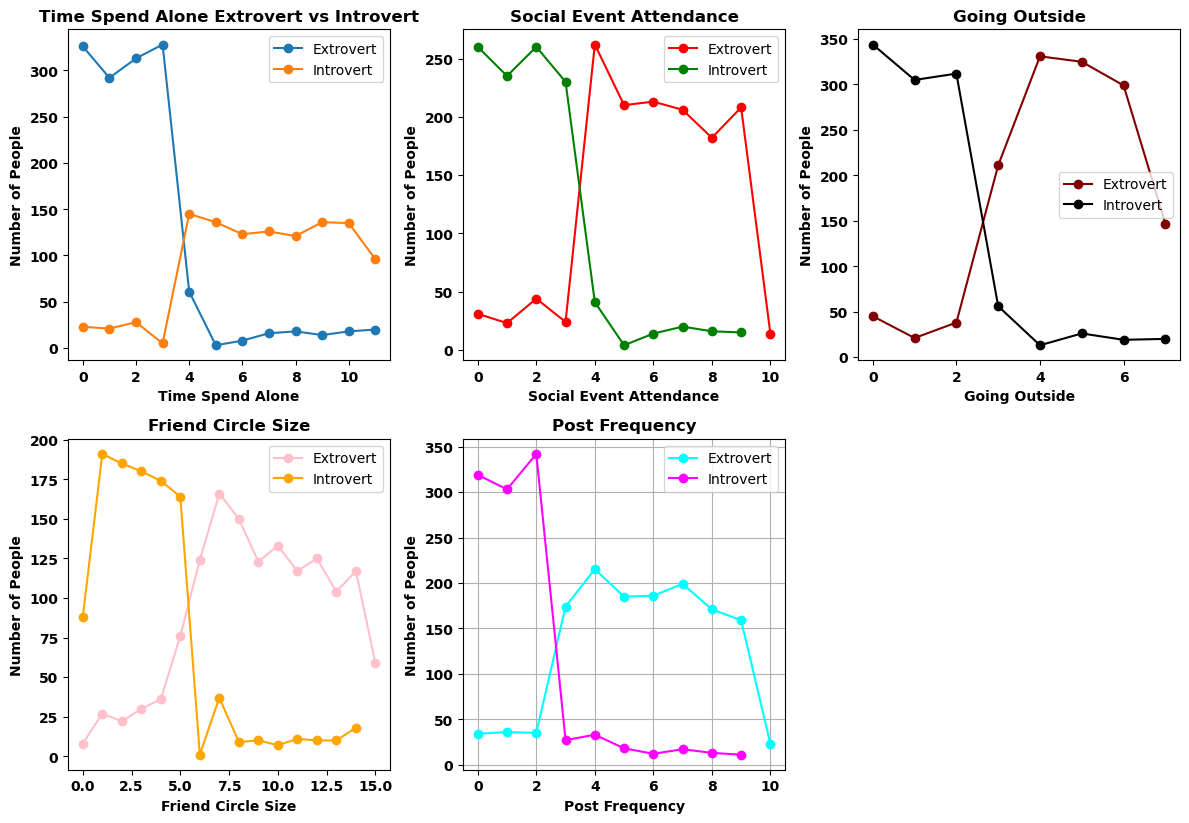

In [25]:
plt.figure(figsize = (12, 12))

plt.subplot(331)
plt.title("Time Spend Alone Extrovert vs Introvert", fontweight = 'bold')
extrovert_time_spend = df_clean[df_clean['Personality'] == 'Extrovert']['Time_spent_Alone'].value_counts().sort_index()
introvert_time_spend = df_clean[df_clean['Personality'] == 'Introvert']['Time_spent_Alone'].value_counts().sort_index()
plt.plot(extrovert_time_spend.index, extrovert_time_spend.values, label = 'Extrovert', marker = 'o')
plt.plot(introvert_time_spend.index, introvert_time_spend.values, label = 'Introvert', marker = 'o')
plt.ylabel("Number of People", fontweight = 'bold')
plt.xlabel("Time Spend Alone", fontweight = 'bold')
plt.xticks(fontweight = 'bold')
plt.yticks(fontweight = 'bold')
plt.legend()

plt.subplot(332)
plt.title("Social Event Attendance", fontweight = 'bold')
extrovert_social = df_clean[df_clean['Personality'] == 'Extrovert']['Social_event_attendance'].value_counts().sort_index()
introvert_social = df_clean[df_clean['Personality'] == 'Introvert']['Social_event_attendance'].value_counts().sort_index()
plt.plot(extrovert_social.index, extrovert_social.values, label = 'Extrovert', marker = 'o', color = 'red')
plt.plot(introvert_social.index, introvert_social.values, label = 'Introvert', marker = 'o', color = 'green')
plt.ylabel("Number of People", fontweight = 'bold')
plt.xlabel("Social Event Attendance", fontweight = 'bold')
plt.xticks(fontweight = 'bold')
plt.yticks(fontweight = 'bold')
plt.legend()

plt.subplot(333)
plt.title("Going Outside", fontweight = 'bold')
extrovert_outside = df_clean[df_clean['Personality'] == 'Extrovert']['Going_outside'].value_counts().sort_index()
introvert_outside = df_clean[df_clean['Personality'] == 'Introvert']['Going_outside'].value_counts().sort_index()
plt.plot(extrovert_outside.index, extrovert_outside.values, label = 'Extrovert', marker = 'o', color = 'maroon')
plt.plot(introvert_outside.index, introvert_outside.values, label = 'Introvert', marker = 'o', color = 'black')
plt.ylabel("Number of People", fontweight = 'bold')
plt.xlabel("Going Outside", fontweight = 'bold')
plt.xticks(fontweight = 'bold')
plt.yticks(fontweight = 'bold')
plt.legend()

plt.subplot(334)
plt.title("Friend Circle Size", fontweight = 'bold')
extrovert_friend = df_clean[df_clean['Personality'] == 'Extrovert']['Friends_circle_size'].value_counts().sort_index()
introvert_friend = df_clean[df_clean['Personality'] == 'Introvert']['Friends_circle_size'].value_counts().sort_index()
plt.plot(extrovert_friend.index, extrovert_friend.values, label = 'Extrovert', marker = 'o', color = 'pink')
plt.plot(introvert_friend.index, introvert_friend.values, label = 'Introvert', marker = 'o', color = 'orange')
plt.ylabel("Number of People", fontweight = 'bold')
plt.xlabel("Friend Circle Size", fontweight = 'bold')
plt.xticks(fontweight = 'bold')
plt.yticks(fontweight = 'bold')
plt.legend()

plt.subplot(335)
plt.title("Post Frequency", fontweight = 'bold')
extrovert_post = df_clean[df_clean['Personality'] == 'Extrovert']['Post_frequency'].value_counts().sort_index()
introvert_post = df_clean[df_clean['Personality'] == 'Introvert']['Post_frequency'].value_counts().sort_index()
plt.plot(extrovert_post.index, extrovert_post.values, label = 'Extrovert', marker = 'o', color = 'cyan')
plt.plot(introvert_post.index, introvert_post.values, label = 'Introvert', marker = 'o', color = 'magenta')
plt.ylabel("Number of People", fontweight = 'bold')
plt.xlabel("Post Frequency", fontweight = 'bold')
plt.xticks(fontweight = 'bold')
plt.yticks(fontweight = 'bold')
plt.legend()

plt.tight_layout()
plt.grid(True)
plt.show()

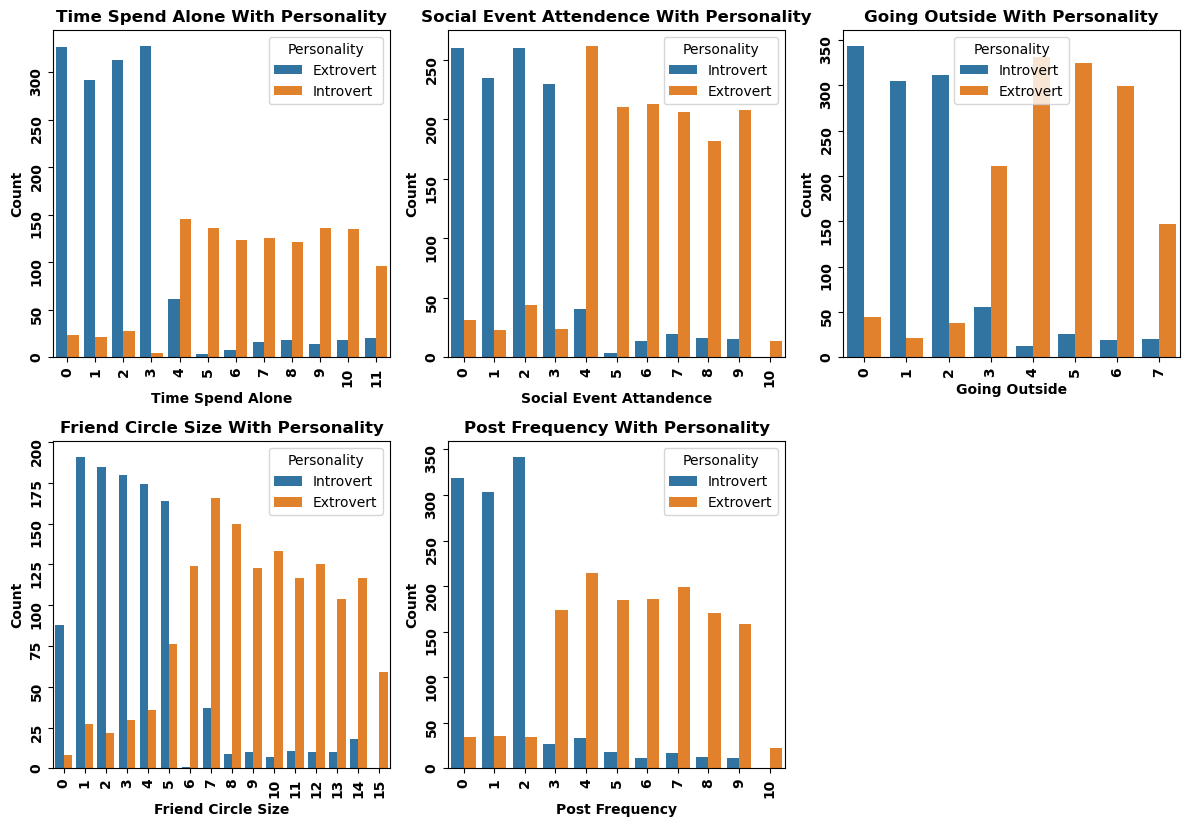

In [26]:
plt.figure(figsize = (12, 12))

plt.subplot(331)
plt.title("Time Spend Alone With Personality", fontweight = 'bold')
sns.countplot(x = df_clean['Time_spent_Alone'], hue = df_clean['Personality'])
plt.xlabel("Time Spend Alone", fontweight = 'bold')
plt.ylabel("Count", fontweight = 'bold')
plt.xticks(fontweight = 'bold', rotation = 90)
plt.yticks(fontweight = 'bold', rotation = 90)

plt.subplot(332)
plt.title("Social Event Attendence With Personality", fontweight = 'bold')
sns.countplot(x = df_clean['Social_event_attendance'], hue = df_clean['Personality'])
plt.xlabel("Social Event Attandence", fontweight = 'bold')
plt.ylabel("Count", fontweight = 'bold')
plt.xticks(fontweight = 'bold', rotation = 90)
plt.yticks(fontweight = 'bold', rotation = 90)

plt.subplot(333)
plt.title("Going Outside With Personality", fontweight = 'bold')
sns.countplot(x = df_clean['Going_outside'], hue = df_clean['Personality'])
plt.xlabel("Going Outside", fontweight = 'bold')
plt.ylabel("Count", fontweight = 'bold')
plt.xticks(fontweight = 'bold', rotation = 90)
plt.yticks(fontweight = 'bold', rotation = 90)

plt.subplot(334)
plt.title("Friend Circle Size With Personality", fontweight = 'bold')
sns.countplot(x = df_clean['Friends_circle_size'], hue = df_clean['Personality'])
plt.xlabel("Friend Circle Size", fontweight = 'bold')
plt.ylabel("Count", fontweight = 'bold')
plt.xticks(fontweight = 'bold', rotation = 90)
plt.yticks(fontweight = 'bold', rotation = 90)

plt.subplot(335)
plt.title("Post Frequency With Personality", fontweight = 'bold')
sns.countplot(x = df_clean['Post_frequency'], hue = df_clean['Personality'])
plt.xlabel("Post Frequency", fontweight = 'bold')
plt.ylabel("Count", fontweight = 'bold')
plt.xticks(fontweight = 'bold', rotation = 90)
plt.yticks(fontweight = 'bold', rotation = 90)

plt.tight_layout()
plt.show()

<Figure size 1200x1200 with 0 Axes>

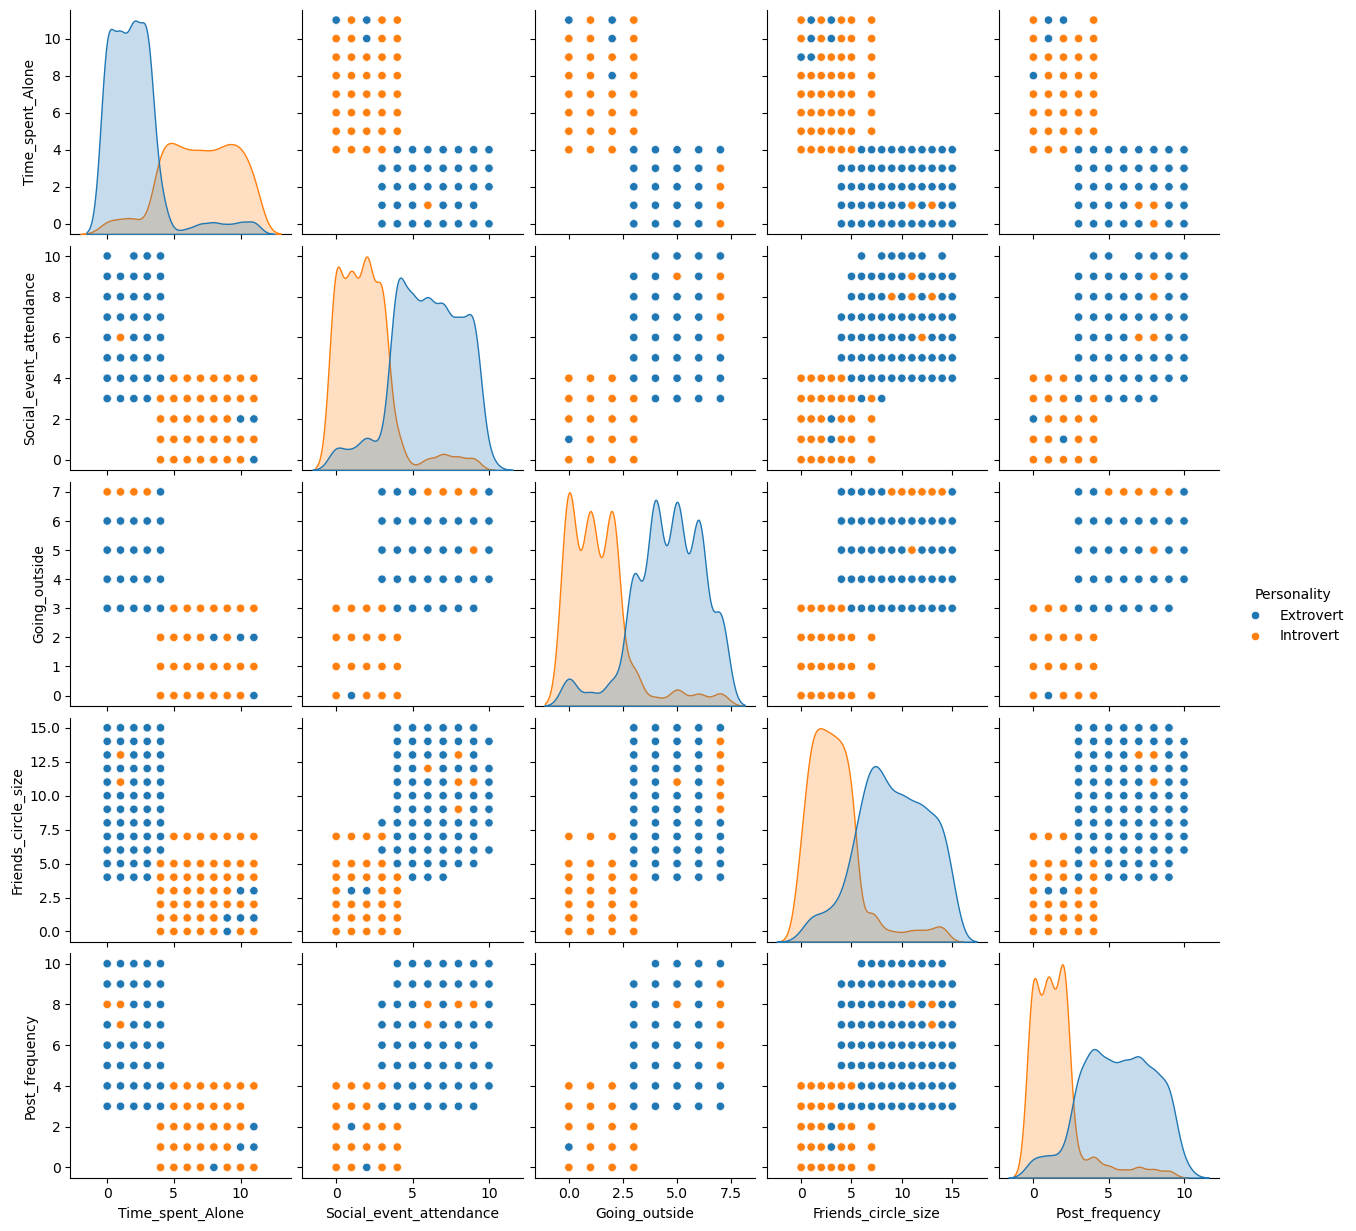

In [27]:
plt.figure(figsize = (12, 12))
num_cols = df_clean.select_dtypes(include = 'int32')
num_cols['Personality'] = df_clean['Personality']
sns.pairplot(num_cols, hue = 'Personality')
plt.show()

In [28]:
# step 8 : split target column and feature column

X = df_clean.drop('Personality', axis = 1)
y = df_clean['Personality']

In [29]:
# step 9 : label encoding target column

le = LabelEncoder()
y = le.fit_transform(y)

In [30]:
# step 10 : train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [31]:
# step 11 : data preprocessing

num_cols = X_train.select_dtypes(include = 'int32').columns
cat_cols = X_train.select_dtypes(include = 'object').columns

preprocess = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

In [32]:
# step 12 : train classification models

models = {
    'LogisticRegression' : LogisticRegression(C = 1, penalty = 'l2', solver = 'lbfgs', max_iter = 100),
    'DecisionTreeClassifier' : DecisionTreeClassifier(min_samples_split = 2, min_samples_leaf = 1, criterion = 'gini', max_depth = 2),
    'RandomForestClassifier' : RandomForestClassifier(max_depth = 2, min_samples_split = 2, min_samples_leaf = 1, criterion = 'gini', n_estimators = 2),
    'SVC' : SVC(C = 1, probability = True),
    'KNeighborsClassifier' : KNeighborsClassifier(n_neighbors = 3)
}

In [33]:
# step 13 : train grid search

grid_search = {
    'LogisticRegression' : {
        'model__C' : [0.001, 0.01, 0.1, 1],
        'model__penalty' : ['l1', 'l2'],
        'model__solver' : ['lbfgs', 'saga', 'liblinear', 'sag'],
        'model__max_iter' : [10, 20, 30, 40]
    },
    'DecisionTreeClassifier' : {
        'model__max_depth' : [1, 2, 3],
        'model__min_samples_split' : [1, 2],
        'model__min_samples_leaf' : [1, 2],
        'model__criterion' : ['gini', 'entropy']
    },
    'RandomForestClassifier' : {
        'model__n_estimators' : [1, 2],
        'model__max_depth' : [1, 2, 3],
        'model__min_samples_split' : [1, 2],
        'model__min_samples_leaf' : [1, 2],
        'model__criterion' : ['gini', 'entropy']
    },
    'SVC' : {
        'model__C' : [0.01, 0.1, 1],
        'model__kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
        
    },
    'KNeighborsClassifier' : {
        'model__n_neighbors' : [1, 2],
        'model__weights' : ['uniform', 'distance'],
        'model__algorithm' : ['kd_tree', 'ball_tree', 'brute'],
        'model__metric' : ['euclidean', 'manhattan', 'minkowski']
    }
}

# choosing best model

best_model = None
best_params = None
best_accuracy = 0

In [34]:
# step 14 : model evalution

for model_name, model in models.items():
    print(f"\n ===== {model_name} ===== \n")

    pipeline = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])

    grid = GridSearchCV(
        estimator = pipeline,
        param_grid = grid_search[model_name],
        scoring = 'accuracy', 
        n_jobs = -1,
        cv = 3
    )

    grid.fit(X_train, y_train)

    print("Params :", grid.best_params_)
    print(f"Accuracy : {grid.best_score_:.2f}")

    if grid.best_score_ > best_accuracy:
        best_accuracy = grid.best_score_
        best_model = model_name
        best_params = grid.best_params_

print("\n ===== Best Model Details ===== \n")
print("Best Model :", best_model)
print("Best Params :", best_params)
print(f"Best Accuracy : {best_accuracy:.2f}")


 ===== LogisticRegression ===== 

Params : {'model__C': 0.001, 'model__max_iter': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Accuracy : 0.93

 ===== DecisionTreeClassifier ===== 

Params : {'model__criterion': 'gini', 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Accuracy : 0.93

 ===== RandomForestClassifier ===== 

Params : {'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 1}
Accuracy : 0.93

 ===== SVC ===== 

Params : {'model__C': 0.01, 'model__kernel': 'rbf'}
Accuracy : 0.93

 ===== KNeighborsClassifier ===== 

Params : {'model__algorithm': 'kd_tree', 'model__metric': 'euclidean', 'model__n_neighbors': 2, 'model__weights': 'uniform'}
Accuracy : 0.87

 ===== Best Model Details ===== 

Best Model : LogisticRegression
Best Params : {'model__C': 0.001, 'model__max_iter': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best Accuracy : 0.93


In [35]:
random_search = {
    'LogisticRegression' : {
        'model__C' : [0.001, 0.01, 0.1, 1],
        'model__penalty' : ['l1', 'l2'],
        'model__solver' : ['lbfgs', 'saga', 'liblinear', 'sag'],
        'model__max_iter' : [10, 20, 30, 40]
    },
    'DecisionTreeClassifier' : {
        'model__max_depth' : [1, 2, 3],
        'model__min_samples_split' : [1, 2],
        'model__min_samples_leaf' : [1, 2],
        'model__criterion' : ['gini', 'entropy']
    },
    'RandomForestClassifier' : {
        'model__n_estimators' : [1, 2],
        'model__max_depth' : [1, 2, 3],
        'model__min_samples_split' : [1, 2],
        'model__min_samples_leaf' : [1, 2],
        'model__criterion' : ['gini', 'entropy']
    },
    'SVC' : {
        'model__C' : [0.01, 0.1, 1],
        'model__kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
        
    },
    'KNeighborsClassifier' : {
        'model__n_neighbors' : [1, 2],
        'model__weights' : ['uniform', 'distance'],
        'model__algorithm' : ['kd_tree', 'ball_tree', 'brute'],
        'model__metric' : ['euclidean', 'manhattan', 'minkowski']
    }
}

# choosing best model

best_model = None
best_params = None
best_accuracy = 0

In [36]:
for model_name, model in models.items():
    print(f"\n ===== {model_name} ===== \n")

    pipeline = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])

    random = RandomizedSearchCV(
        estimator = pipeline,
        param_distributions = random_search[model_name],
        scoring = 'accuracy',
        random_state = 42,
        n_iter = 10,
        n_jobs = -1,
        cv = 3)

    random.fit(X_train, y_train)

    print("Best Params :", random.best_params_)
    print(f"Accuracy : {random.best_score_:.2f}")

    if random.best_score_ > best_accuracy:
        best_accuracy = random.best_score_
        best_model = model_name
        best_params = random.best_params_

print("\n ===== Best Model Details ===== \n")
print("Best Model :", best_model)
print("Best Params :", best_params)
print(f"Best Accuracy : {best_accuracy:.2f}")


 ===== LogisticRegression ===== 

Best Params : {'model__solver': 'sag', 'model__penalty': 'l2', 'model__max_iter': 30, 'model__C': 0.01}
Accuracy : 0.93

 ===== DecisionTreeClassifier ===== 

Best Params : {'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__criterion': 'gini'}
Accuracy : 0.93

 ===== RandomForestClassifier ===== 

Best Params : {'model__n_estimators': 2, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__criterion': 'entropy'}
Accuracy : 0.93

 ===== SVC ===== 

Best Params : {'model__kernel': 'rbf', 'model__C': 1}
Accuracy : 0.93

 ===== KNeighborsClassifier ===== 

Best Params : {'model__weights': 'uniform', 'model__n_neighbors': 2, 'model__metric': 'euclidean', 'model__algorithm': 'brute'}
Accuracy : 0.87

 ===== Best Model Details ===== 

Best Model : LogisticRegression
Best Params : {'model__solver': 'sag', 'model__penalty': 'l2', 'model__max_iter': 30, 'model__C': 0.01}
Best Accur

In [37]:
bayes_search = {
    'LogisticRegression' : {
        'model__C' : [0.001, 0.01, 0.1, 1],
        'model__penalty' : ['l1', 'l2'],
        'model__solver' : ['lbfgs', 'saga', 'liblinear', 'sag'],
        'model__max_iter' : [10, 20, 30, 40]
    },
    'DecisionTreeClassifier' : {
        'model__max_depth' : [1, 2, 3],
        'model__min_samples_split' : [2, 3],
        'model__min_samples_leaf' : [1, 2],
        'model__criterion' : ['gini', 'entropy']
    },
    'RandomForestClassifier' : {
        'model__n_estimators' : [1, 2],
        'model__max_depth' : [1, 2, 3],
        'model__min_samples_split' : [2, 3],
        'model__min_samples_leaf' : [1, 2],
        'model__criterion' : ['gini', 'entropy']
    },
    'SVC' : {
        'model__C' : [0.01, 0.1, 1],
        'model__kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
        
    },
    'KNeighborsClassifier' : {
        'model__n_neighbors' : [1, 2],
        'model__weights' : ['uniform', 'distance'],
        'model__algorithm' : ['kd_tree', 'ball_tree', 'brute'],
        'model__metric' : ['euclidean', 'manhattan', 'minkowski']
    }
}

# choosing best model

best_model = None
best_params = None
best_accuracy = 0

In [38]:
for model_name, model in models.items():
    print(f"\n ===== {model_name} ===== \n")

    pipeline = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])

    opt = BayesSearchCV(
        estimator = pipeline,
        search_spaces = bayes_search[model_name],
        scoring = 'accuracy',
        n_jobs = -1,
        cv = 3,
        n_iter = 10,
        random_state = 10)

    opt.fit(X_train, y_train)

    print("Best Params :", opt.best_params_)
    print(f"Accuracy : {opt.best_score_:.2f}")

    if opt.best_score_ > best_accuracy:
        best_accuracy = opt.best_score_
        best_model = model_name
        best_params = opt.best_params_

print("\n ===== Best Model Details ===== \n")
print("Best Model :", best_model)
print("Best Params :", best_params)
print(f"Best Accuracy : {best_accuracy:.2f}")


 ===== LogisticRegression ===== 

Best Params : OrderedDict({'model__C': 0.001, 'model__max_iter': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'})
Accuracy : 0.93

 ===== DecisionTreeClassifier ===== 

Best Params : OrderedDict({'model__criterion': 'entropy', 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3})
Accuracy : 0.93

 ===== RandomForestClassifier ===== 

Best Params : OrderedDict({'model__criterion': 'entropy', 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 2})
Accuracy : 0.93

 ===== SVC ===== 

Best Params : OrderedDict({'model__C': 1, 'model__kernel': 'poly'})
Accuracy : 0.93

 ===== KNeighborsClassifier ===== 

Best Params : OrderedDict({'model__algorithm': 'kd_tree', 'model__metric': 'euclidean', 'model__n_neighbors': 2, 'model__weights': 'uniform'})
Accuracy : 0.87

 ===== Best Model Details ===== 

Best Model : LogisticRegression
Best Params : OrderedDict({'model__C

In [39]:
cv_methods = {
    'KFold' : KFold(n_splits = 3, shuffle = True, random_state = 42),
    'StratifiedKFold' : StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42),
    'RepeatedKFold' : RepeatedKFold(n_splits = 3, n_repeats = 3, random_state = 42),
    'ShuffleSplit' : ShuffleSplit(n_splits = 3, test_size = 0.2, random_state = 42)
}

# choosing best model

best_model = None
best_method = None
best_accuracy = 0

In [40]:
for model_name, model in models.items():
    print(f"\n ===== {model_name} ===== \n")
    for method_name, method in cv_methods.items():
        pipeline = Pipeline([
        ('preprocess', preprocess),
        ('model', model)])
        
        cv_score = cross_val_score(pipeline, X_train, y_train, cv = method, scoring = 'accuracy').mean()
        
        print(f"{method_name} : {cv_score:.2f}")
        
        if cv_score > best_accuracy:
            best_accuracy = cv_score
            best_model = model_name
            best_method = method_name

print("\n ===== Best Model Details ===== \n")
print("Best Model :", best_model)    
print("Best Method :", best_method)
print(f"Best Accurcay : {best_accuracy:.2f}")


 ===== LogisticRegression ===== 

KFold : 0.92
StratifiedKFold : 0.92
RepeatedKFold : 0.92
ShuffleSplit : 0.91

 ===== DecisionTreeClassifier ===== 

KFold : 0.93
StratifiedKFold : 0.93
RepeatedKFold : 0.93
ShuffleSplit : 0.94

 ===== RandomForestClassifier ===== 

KFold : 0.93
StratifiedKFold : 0.93
RepeatedKFold : 0.93
ShuffleSplit : 0.94

 ===== SVC ===== 

KFold : 0.93
StratifiedKFold : 0.93
RepeatedKFold : 0.93
ShuffleSplit : 0.94

 ===== KNeighborsClassifier ===== 

KFold : 0.91
StratifiedKFold : 0.92
RepeatedKFold : 0.91
ShuffleSplit : 0.91

 ===== Best Model Details ===== 

Best Model : SVC
Best Method : ShuffleSplit
Best Accurcay : 0.94


In [41]:
# step 15 : choose final model

final_model = Pipeline([
    ('preprocess', preprocess),
    ('model', models[best_model])
])

final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Stage_fear', 'Drained_after_socializing'], dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['Time_spent_Alone', 'Social_event_attendance', 'Going_outside',
       'Friends_circle_size', 'Post_frequency'],
      dtype='object'))])),
                ('model', SVC(C=1, probability=True))])

In [42]:
# step 16 : predict final model 

y_pred = final_model.predict(X_test)

In [43]:
# step 17 : model performance

print("Classification Report :\n", classification_report(y_test, y_pred))

Classification Report :
               precision    recall  f1-score   support

           0       0.94      0.90      0.92       284
           1       0.88      0.93      0.90       219

    accuracy                           0.91       503
   macro avg       0.91      0.92      0.91       503
weighted avg       0.92      0.91      0.91       503



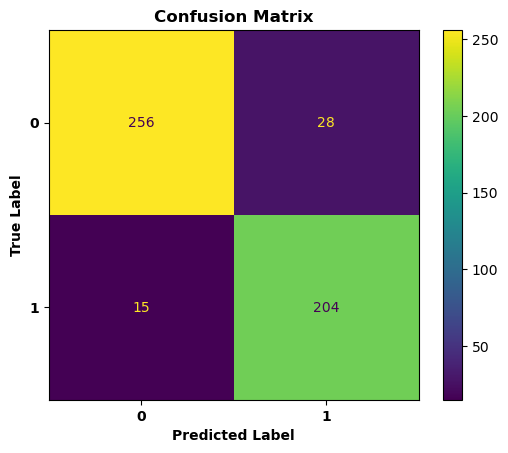

In [44]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix = cm).plot()
plt.title("Confusion Matrix", fontweight = 'bold')
plt.xlabel("Predicted Label", fontweight = 'bold')
plt.ylabel("True Label", fontweight = 'bold')
plt.xticks(fontweight = 'bold')
plt.yticks(fontweight = 'bold')
plt.show()

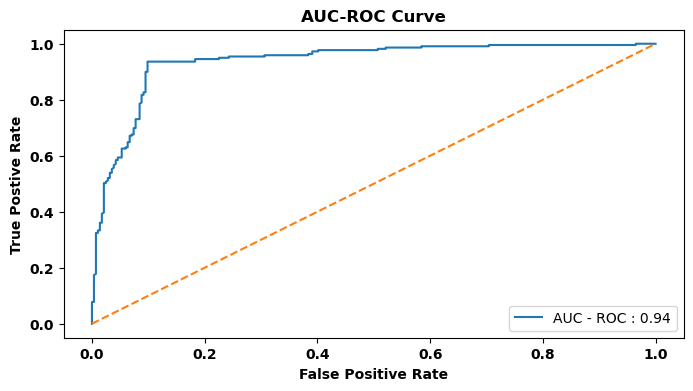

In [45]:
y_prob = final_model.predict_proba(X_test)[:, 1]

score = roc_auc_score(y_test, y_prob) 

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize = (8, 4))
plt.title("AUC-ROC Curve", fontweight = 'bold')
plt.plot(fpr, tpr, label = f"AUC - ROC : {score:.2f}")
plt.plot([0, 1], [0, 1], linestyle = '--')
plt.xlabel("False Positive Rate", fontweight = 'bold')
plt.ylabel("True Postive Rate", fontweight = 'bold')
plt.xticks(fontweight = 'bold')
plt.yticks(fontweight = "bold")
plt.legend()
plt.show()

In [46]:
# step 19 : save model for deplaoyment

joblib.dump({
    'label_encoder' : le,
    'pipeline' : final_model
}, 'personality_prediction.pkl')

print("Model Saved Successfully...!")

Model Saved Successfully...!
